## Loading dataset

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
# from sklearn.metrics import plot_roc_curve
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
df = pd.read_csv('annotated_data/final/final_dataset.csv')

In [ ]:
df

,question_0_This post is:,question_1_Total relationship duration,question_2_Current relationship status,question_3_How would you rate the risk level of the woman's relationship based on the information provided in the post?,question_4_Does she mention avoiding social events or outings with friends or family because of him or maybe making excuses for not going out?,"question_5_Does she frequently feel anxious in her interactions with him, as if she needs to be careful with her words and actions?",question_6_Does he frequently make her feel guilty?,question_7_Does he frequently express dissatisfaction with her?,question_8_Does he try to manipulate her?,question_9_Does she feel she doesn't have option to leave him?,...,upvote_ratio,downs,URL,over18,TOXICITY,THREAT,PROFANITY,INSULT,IDENTITY_ATTACK,example_id
0,'relevant','unclear from the post','boyfriend/girlfriend dating','medium','no','yes','yes','yes','yes','no',...,1.00,0,/r/relationship_advice/comments/132jzyg/i_18f_...,False,0.039936,0.007664,0.041411,0.017550,0.005698,NaN
1,'relevant','unclear from the post','boyfriend/girlfriend dating','low','no','no','no','no','no','no',...,0.33,0,/r/relationship_advice/comments/132i8ih/should...,False,0.072920,0.007793,0.028094,0.025027,0.052490,NaN
2,'irrelevant','0-1 year','separated/divorced','low','no','no','no','no','no','no',...,1.00,0,/r/relationship_advice/comments/1327rpt/me_m27...,False,0.237399,0.010033,0.196476,0.111722,0.026811,NaN
3,'relevant','unclear from the post','boyfriend/girlfriend dating','low','no','no','no','no','no','no',...,0.50,0,/r/relationship_advice/comments/132k9s2/my_f20...,False,0.154903,0.019746,0.116018,0.038859,0.021987,NaN
4,'relevant','unclear from the post','partners/married','low','no','no','no','no','yes','no',...,0.50,0,/r/relationship_advice/comments/131giic/i_34f_...,False,0.321823,0.023717,0.384838,0.091242,0.058402,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,'relevant','3+ years long','partners/married','low','no','no','no','no','no','no',...,1.00,0,/r/relationship_advice/comments/131kqc9/i_f26_...,False,0.166786,0.008712,0.134326,0.067046,0.008916,NaN
291,'relevant','3+ years long','partners/married','high','no','no','no','yes','yes','yes',...,0.50,0,/r/relationship_advice/comments/131qbmo/ive_24...,False,0.169385,0.011768,0.090987,0.062501,0.015355,NaN
292,'irrelevant','0-1 year',separated/divorced','low','no','no','no','no','no','no',...,0.20,0,/r/relationship_advice/comments/132fesb/my_22m...,False,0.095684,0.008130,0.021330,0.037688,0.023394,NaN
293,'relevant','1-3 years','boyfriend/girlfriend dating','low','no','no','no','no','no','no',...,0.50,0,/r/relationship_advice/comments/131ffk2/i_19f_...,False,0.045131,0.007237,0.034898,0.019741,0.013345,NaN


## Data cleaning

In [158]:
# Fixing data representation:
fixing_columns = ['question_0_This post is:',
                  'question_2_Current relationship status',
       "question_3_How would you rate the risk level of the woman's relationship based on the information provided in the post?",
       'question_4_Does she mention avoiding social events or outings with friends or family because of him or maybe making excuses for not going out?',
       'question_5_Does she frequently feel anxious in her interactions with him, as if she needs to be careful with her words and actions?',
       'question_6_Does he frequently make her feel guilty?',
       'question_7_Does he frequently express dissatisfaction with her?',
       'question_8_Does he try to manipulate her?',
       "question_9_Does she feel she doesn't have option to leave him?",
       'question_10_Has she mentioned feeling like she has to dress, appear or act a certain way to please him?',
       'question_11_Does he exhibit a tendency for angry outbursts?',
       'question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?',
       'question_13_Does she mention that he was physically violent to her?',
       'question_14_Does she mention that he was physically violent towards objects/animals related to her?',
       'question_15_Does she describe verbal violence from her partner? (e.g. name calling/humilation)']
for column in fixing_columns:
  df[column] = df[column].apply(lambda x: x[1:-1])

In [159]:
# Filter irelevent posts
df = df[df['question_0_This post is:'] == 'relevant']

In [160]:
# vectorize the datafram:
df = df.replace({'yes': 1, 'no': 0})

In [161]:
df['question_2_Current relationship status'].unique()

array(['boyfriend/girlfriend dating', 'partners/married', 'friends',
       'non committed relationship', 'separated/divorced', 'affair',
       'on committed relationship', 'unclear from the post',
       'oyfriend/girlfriend dating', "'separated/divorced",
       'non commited relationship', 'eparated/divorced'], dtype=object)

In [162]:
df = df.replace({'affair': "non committed relationship",  'on committed relationshi': "non committed relationship",
                 'n committed relationshi': "non committed relationship",
                 'parated/divorced': 'separated/divorce', 'eparated/divorced': 'separated/divorced',
                 'oyfriend/girlfriend dating': 'boyfriend/girlfriend dating',
                 'non commited relationship': "non committed relationship",
                 'on committed relationship': "non committed relationship",
                 'eparated/divorced': 'separated/divorced', "'separated/divorced": 'separated/divorced'})

In [163]:
df['question_2_Current relationship status'].unique()

array(['boyfriend/girlfriend dating', 'partners/married', 'friends',
       'non committed relationship', 'separated/divorced',
       'unclear from the post'], dtype=object)

In [164]:
df.to_csv("annotated_data/final/final_dataset_clean.csv")

In [62]:
# Transform categorical features to integers:
df['question_1_Total relationship duration'] = df['question_1_Total relationship duration'].astype('category').cat.codes
df['question_2_Current relationship status'] = df['question_2_Current relationship status'].astype('category').cat.codes

In [63]:
# Dump redundant columns
df = df.drop(columns=['question_0_This post is:','downs', 'URL', 'over18', 'User Name', 'Post time', 'Subreddit', 'round_id', 'index', 'originalIndex', 'part'])

In [64]:
# toxicity_df = df[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
# df = df.drop(columns=['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK'])

In [65]:
# Unify title and text:
df['text'] = df['title'] + " " + df['text']
df = df.drop(columns=['title'])

In [66]:
import string
def clean_text(text):
  non_alpha_chars = string.punctuation + string.digits + '�' +  'ï¿½'
  new_string = text.translate(str.maketrans('', '', non_alpha_chars))
  return new_string


In [67]:
df['clean_text'] = df["text"].apply(clean_text)

In [68]:
# Encode the label
# labelencoder = LabelEncoder()
# df['question_3_How would you rate the risk level of the woman\'s relationship based on the information provided in the post?'] = labelencoder.fit_transform(df['question_3_How would you rate the risk level of the woman\'s relationship based on the information provided in the post?'])

df = df.replace({'low': 0, 'medium': 1, "medium'":1, 'high':3})

In [69]:
df = df.dropna(subset=['question_3_How would you rate the risk level of the woman\'s relationship based on the information provided in the post?'])

In [70]:
# Split to train, validation and test
X = df.drop(columns='question_3_How would you rate the risk level of the woman\'s relationship based on the information provided in the post?')
y = df['question_3_How would you rate the risk level of the woman\'s relationship based on the information provided in the post?']
train_test_only = True

if train_test_only:
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
else:
  # If validation and test set are desired:
  X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42)
  X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


## Models

### Model 1 - tf-df features, predicting subjective question

In [71]:
model_info = '1_tfidf_only'

In [72]:
label_columns = ['low', 'medium', 'high']

In [73]:
X_train[['clean_text', "text"]]

,clean_text,text
58,Is he M not in love with me F My boyfriend M a...,Is he (29M) not in love with me? (29F) My boyf...
54,How can I F get over the fact that he M doesnt...,How can I (22F) get over the fact that he (39M...
202,F good news from my bf M Today This is really ...,(26F) good news from my bf (26M) Today This is...
245,The guy Im talking to M for months called me ...,The guy I�m talking to (22M) for 5 months call...
88,I F am dating a guy Mwho is recently broke up ...,I(29 F) am dating a guy(30 M)who is recently b...
...,...,...
282,Are me F and my bfM toxic for having attachmen...,Are me (F21) and my bf(M21) toxic for having a...
65,When should you start talking about the seriou...,"When should you start talking about the ""serio..."
55,My F boyfriend M has made me uncomfortable wit...,My (22F) boyfriend (22M) has made me uncomfort...
184,My husband m told me f that Ive gained a lot o...,My husband 32m told me 28f that I�ve gained a ...


In [74]:
tfidf = TfidfVectorizer(max_features=1000, stop_words="english", min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train['clean_text'])
if not train_test_only:
  X_val_tfidf = tfidf.transform(X_val['clean_text'])
X_test_tfidf = tfidf.transform(X_test['clean_text'])

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier()
lr = LogisticRegression(max_iter=1000)

voting_clf = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='soft')
voting_clf.fit(X_train_tfidf, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('rf', RandomForestClassifier())],
                 voting='soft')

In [76]:
# Model Evaluation
y_pred_train = voting_clf.predict(X_train_tfidf)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

if not train_test_only:
  y_pred_val = voting_clf.predict(X_val_tfidf)
  print(f'Validation results: \n{classification_report(y_val, y_pred_val, target_names = label_columns)}')

y_pred_test = voting_clf.predict(X_test_tfidf)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       0.93      1.00      0.96       164
      medium       1.00      0.73      0.84        26
        high       1.00      0.65      0.79        17

    accuracy                           0.94       207
   macro avg       0.98      0.79      0.86       207
weighted avg       0.94      0.94      0.93       207

Test results: 
              precision    recall  f1-score   support

         low       0.78      1.00      0.88        54
      medium       0.00      0.00      0.00         9
        high       0.00      0.00      0.00         6

    accuracy                           0.78        69
   macro avg       0.26      0.33      0.29        69
weighted avg       0.61      0.78      0.69        69



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [77]:
# ROC AUC
train_probs = voting_clf.predict_proba(X_train_tfidf)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf.predict_proba(X_val_tfidf)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs, multi_class='ovo'))

test_probs = voting_clf.predict_proba(X_test_tfidf)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class='ovo'))

Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.7145061728395062


confusion matrix

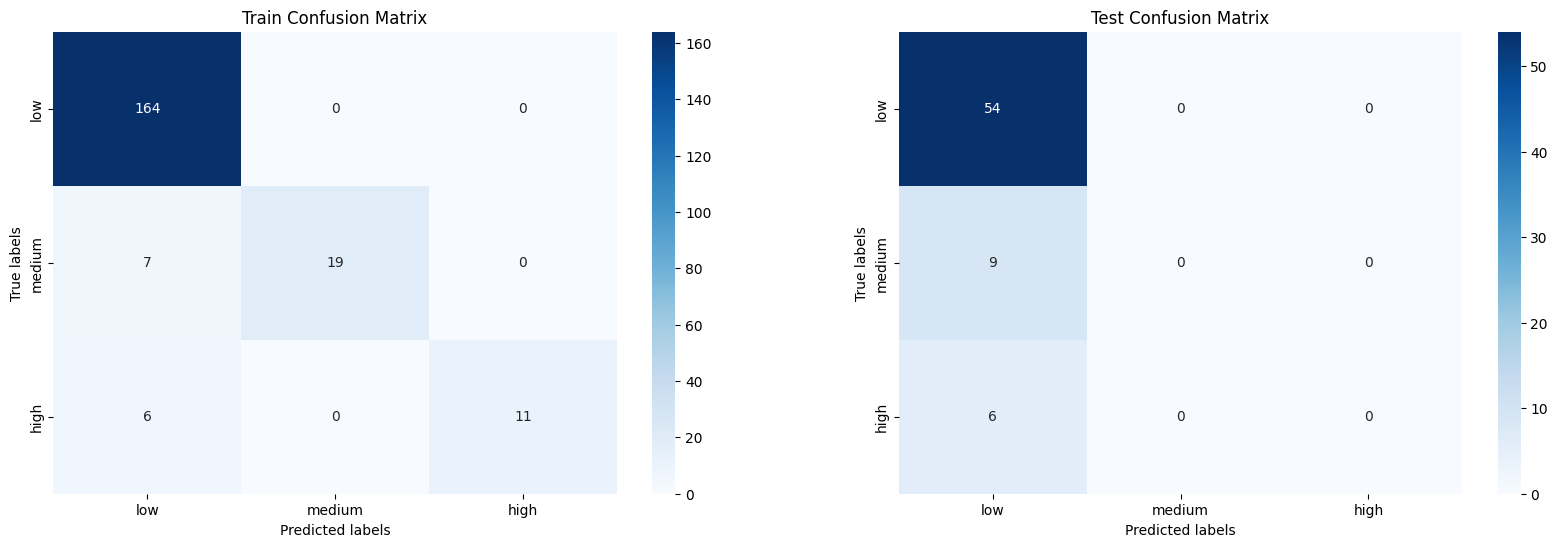

In [78]:
cm_train = confusion_matrix(y_train, y_pred_train)
if not train_test_only:
  cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

if not train_test_only:
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))
else:
  fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
if not train_test_only:
  sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[2], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
else:
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)

if not train_test_only:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Validation Confusion Matrix')
  axes[2].set_title('Test Confusion Matrix')
else:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Test Confusion Matrix')

for ax in axes:
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.show()

In [80]:
# Saving
df_train = pd.DataFrame({'text': X_train.text,
                         'ground_truth': y_train,
                         'model_prediction': y_pred_train})
df_train.to_csv(f'model_{model_info}_train.csv', index=False)

# For the validation set, only if train_test_only is not True
if not train_test_only:
    df_val = pd.DataFrame({'text': X_val.text,
                           'ground_truth': y_val,
                           'model_prediction': y_pred_val})
    df_val.to_csv(f'model_{model_info}_validation.csv', index=False)

# For the test set
df_test = pd.DataFrame({'text': X_test.text,
                        'ground_truth': y_test,
                        'model_prediction': y_pred_test})
df_test.to_csv(f'model_{model_info}_test.csv', index=False)


#### Feature Importance - model 1

In [81]:
# Using Random Forest
feature_names = tfidf.get_feature_names_out()

rf.fit(X_train_tfidf, y_train)

importances = rf.feature_importances_

feat_importances = dict(zip(feature_names, importances))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:30]:
    print(f"Feature: {feat}, Importance: {round(importance,5)}")


Feature: fight, Importance: 0.01519
Feature: sleeping, Importance: 0.01499
Feature: quickly, Importance: 0.00899
Feature: hurtful, Importance: 0.00859
Feature: abusive, Importance: 0.00851
Feature: started, Importance: 0.00809
Feature: thinks, Importance: 0.00664
Feature: minutes, Importance: 0.00657
Feature: problem, Importance: 0.00656
Feature: behavior, Importance: 0.0064
Feature: wall, Importance: 0.00638
Feature: calls, Importance: 0.00637
Feature: members, Importance: 0.0063
Feature: afraid, Importance: 0.00623
Feature: shit, Importance: 0.00615
Feature: things, Importance: 0.00615
Feature: knows, Importance: 0.00588
Feature: anytime, Importance: 0.00584
Feature: accused, Importance: 0.00569
Feature: try, Importance: 0.00536
Feature: im, Importance: 0.00528
Feature: hurts, Importance: 0.00527
Feature: trust, Importance: 0.00526
Feature: spoke, Importance: 0.00525
Feature: away, Importance: 0.00508
Feature: love, Importance: 0.00507
Feature: family, Importance: 0.00491
Feature: fe

In [82]:
# Using Logistic Regression
lr.fit(X_train_tfidf, y_train)

for label in range(0,3):
  print('##########################')
  print(f"label = {label}")
  coef = lr.coef_[label]
  feat_importances = dict(zip(feature_names, coef))
  print(f"highest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
      print(f"Feature: {feat}, Coefficient: {importance}")

  print(f"lowest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=False)[:10]:
      print(f"Feature: {feat}, Coefficient: {importance}")


##########################
label = 0
highest:
Feature: birthday, Coefficient: 0.36888519370814826
Feature: date, Coefficient: 0.3554792492513931
Feature: just, Coefficient: 0.35373931175400497
Feature: friend, Coefficient: 0.34116250474492765
Feature: doesnt, Coefficient: 0.33639353172265263
Feature: bf, Coefficient: 0.32360366471749147
Feature: daughter, Coefficient: 0.32116225278202815
Feature: group, Coefficient: 0.3175447596058661
Feature: let, Coefficient: 0.29192758311759937
Feature: confused, Coefficient: 0.2854996467007682
lowest:
Feature: mom, Coefficient: -0.6666750397589567
Feature: things, Coefficient: -0.57903457350997
Feature: fight, Coefficient: -0.559837008975126
Feature: reach, Coefficient: -0.5290041505737331
Feature: bad, Coefficient: -0.528153837678616
Feature: trust, Coefficient: -0.5065987541075662
Feature: father, Coefficient: -0.4760561542458997
Feature: abusive, Coefficient: -0.45466196955337485
Feature: wall, Coefficient: -0.43142152165059816
Feature: try, Coe

<ipython-input-83-d1071c584d59>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


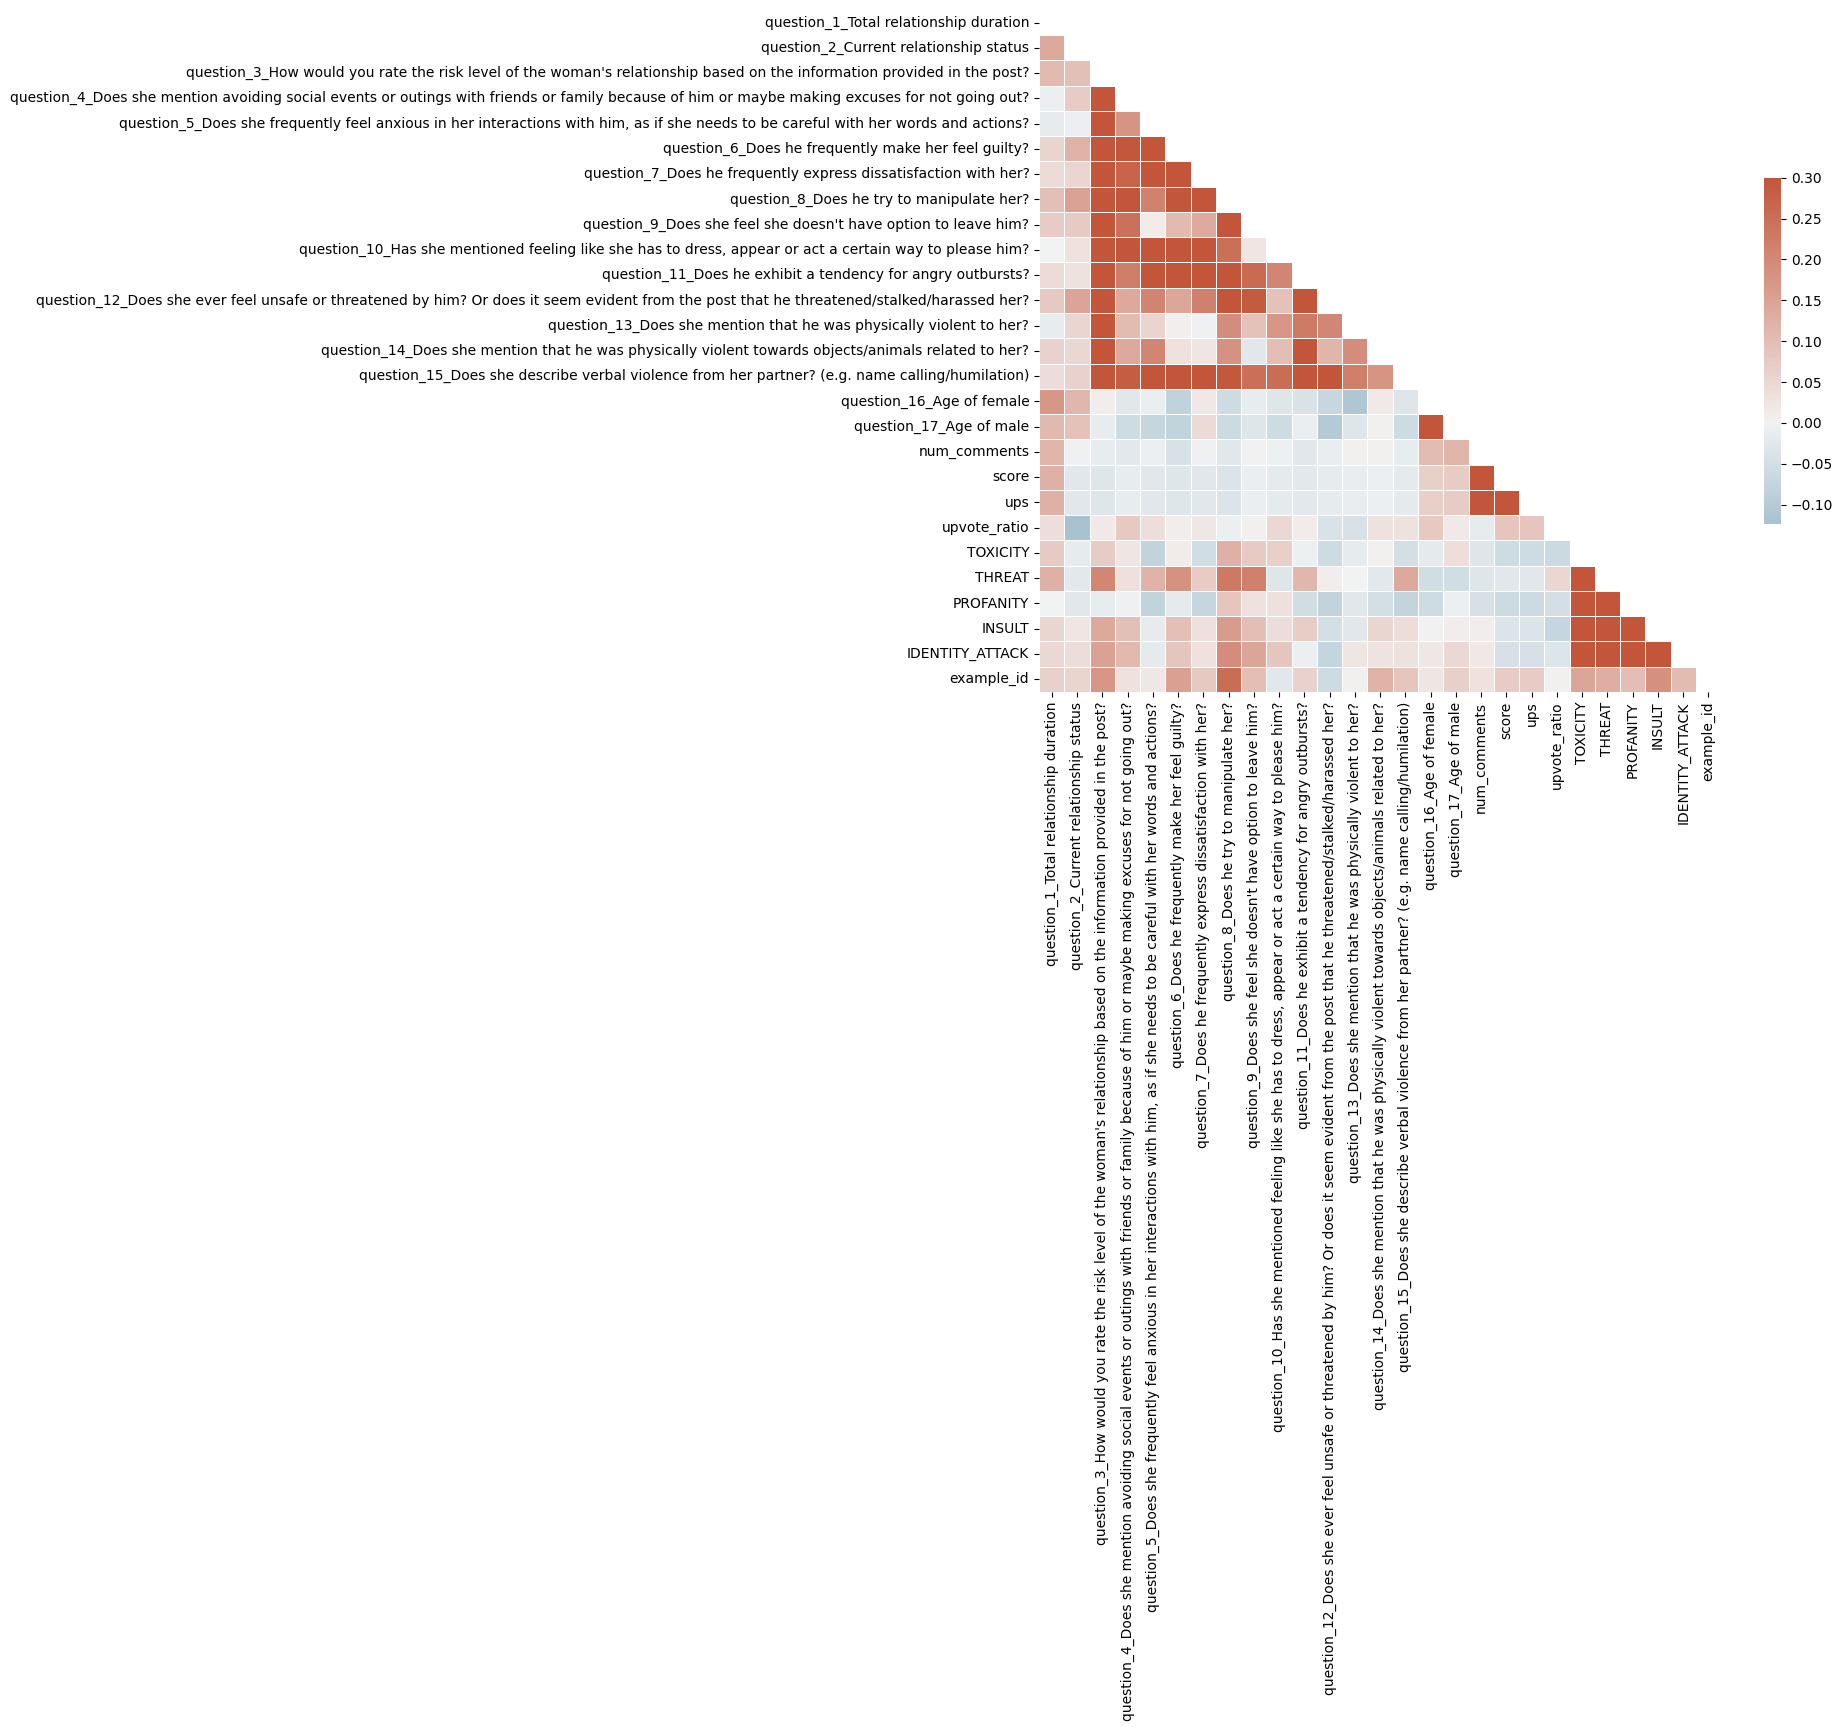

In [83]:
# Correlation matrix with Heatmap for the features: questions + toxicity + meta data
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()


### Model 1.5 tf idf questions + subjective + balance + stemming + feature selection

In [84]:
from nltk.stem import SnowballStemmer
import nltk
nltk.download('punkt')
stemmer = SnowballStemmer('english')

def stem_text(text):
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(token) for token in tokens]
    return stems

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [85]:
tfidf = TfidfVectorizer(max_features=1000, tokenizer=stem_text, stop_words='english', min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train['clean_text'])
if not train_test_only:
  X_val_tfidf = tfidf.transform(X_val['clean_text'])
X_test_tfidf = tfidf.transform(X_test['clean_text'])

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [86]:
X_train_tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index)
X_train_tfidf_df.columns = tfidf.get_feature_names_out()


X_test_tfidf_df = pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index)
X_test_tfidf_df.columns = tfidf.get_feature_names_out()


In [87]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif


KBest_selector = SelectKBest(score_func=f_classif, k=20)

selected_features_matrix = KBest_selector.fit_transform(X_train_tfidf_df, y_train)
# Get columns to keep
cols = KBest_selector.get_support(indices=True)

# Create new dataframe with only the desired columns
X_train_selected = X_train_tfidf_df.iloc[:, cols]
X_test_selected = X_test_tfidf_df.iloc[:, cols]

feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names)
features_names_selected = [f for i, f in enumerate(feature_names) if i in cols]

features_names_selected[:10]

['abus',
 'accus',
 'allow',
 'apolog',
 'beg',
 'boy',
 'cours',
 'disagr',
 'door',
 'fix']

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_15 = RandomForestClassifier(class_weight='balanced')
lr_15 = LogisticRegression(class_weight='balanced', max_iter=1000)

voting_clf_15 = VotingClassifier(estimators=[('lr', lr_15), ('rf', rf_15)], voting='soft')
voting_clf_15.fit(X_train_selected, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced'))],
                 voting='soft')

In [89]:
# Model Evaluation
y_pred_train = voting_clf_15.predict(X_train_selected)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')


y_pred_test = voting_clf_15.predict(X_test_selected)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       1.00      1.00      1.00       164
      medium       1.00      1.00      1.00        26
        high       1.00      1.00      1.00        17

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207

Test results: 
              precision    recall  f1-score   support

         low       0.84      0.94      0.89        54
      medium       0.50      0.22      0.31         9
        high       0.50      0.33      0.40         6

    accuracy                           0.80        69
   macro avg       0.61      0.50      0.53        69
weighted avg       0.76      0.80      0.77        69



In [90]:
# ROC AUC
train_probs = voting_clf_15.predict_proba(X_train_selected)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf_15.predict_proba(X_val_tfidf)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs))

test_probs = voting_clf_15.predict_proba(X_test_selected)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class= 'ovo'))

Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.7885802469135802


In [91]:
# missclassification
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Get unique labels from y_test
labels = [0, 1, 3]

# Calculate misclassification rate for each label
misclassification_rates = []
for i, label in enumerate(labels):
    correct_predictions = cm[i][i]
    total_predictions = cm[i , :].sum()
    misclassification_rate = 1 - (correct_predictions / total_predictions)
    misclassification_rates.append(misclassification_rate)

# Print misclassification rates for each label
for label, rate in zip(labels, misclassification_rates):
    print(f'Misclassification rate for label {label}: {rate}')

Misclassification rate for label 0: 0.05555555555555558
Misclassification rate for label 1: 0.7777777777777778
Misclassification rate for label 3: 0.6666666666666667


In [92]:
# indices of misclassified posts
model15_df = X_test.copy()
model15_df['y_pred_test'] = y_pred_test
model15_df['y_test'] = y_test
model15_df['missclassified'] = model15_df['y_test'] != model15_df['y_pred_test']


In [93]:
model15_df[model15_df['missclassified']].index

Int64Index([31, 126, 42, 189, 0, 254, 230, 77, 270, 266, 29, 212, 260, 289], dtype='int64')

### Model 2 - - tf-df, questions and toxicity features, predicting subjective question

In [94]:
model_info = '2_tfidf_questions_TOXICITY'

In [95]:
train_questions_df = X_train[X_train.columns[X_train.columns.str.startswith('question')]]
train_toxicity_df = X_train[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_train_toxicity = pd.concat([pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index), train_toxicity_df, train_questions_df], axis=1)
X_train_toxicity.columns = X_train_toxicity.columns.astype(str)

if not train_test_only:
  val_questions_df = X_val[X_val.columns[X_val.columns.str.startswith('question')]]
  val_toxicity_df = X_val[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
  X_val_toxicity = pd.concat([pd.DataFrame(X_val_tfidf.toarray(), index=X_val.index), val_toxicity_df, val_questions_df], axis=1)
  X_val_toxicity.columns = X_val_toxicity.columns.astype(str)


test_questions_df = X_test[X_test.columns[X_test.columns.str.startswith('question')]]
test_toxicity_df = X_test[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_test_toxicity = pd.concat([pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index), test_toxicity_df, test_questions_df], axis=1)
X_test_toxicity.columns = X_test_toxicity.columns.astype(str)


In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_2 = RandomForestClassifier()
lr_2 = LogisticRegression(max_iter=1000)
voting_clf_2 = VotingClassifier(estimators=[('lr', lr_2), ('rf', rf_2)], voting='soft')
voting_clf_2.fit(X_train_toxicity, y_train)


VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('rf', RandomForestClassifier())],
                 voting='soft')

In [97]:
# Model Evaluation
y_pred_train = voting_clf_2.predict(X_train_toxicity)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

if not train_test_only:
  y_pred_val = voting_clf_2.predict(X_val_toxicity)
  print(f'Validation results: \n{classification_report(y_val, y_pred_val, target_names = label_columns)}')

y_pred_test = voting_clf_2.predict(X_test_toxicity)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       0.98      1.00      0.99       164
      medium       1.00      0.85      0.92        26
        high       1.00      1.00      1.00        17

    accuracy                           0.98       207
   macro avg       0.99      0.95      0.97       207
weighted avg       0.98      0.98      0.98       207

Test results: 
              precision    recall  f1-score   support

         low       0.91      0.98      0.95        54
      medium       0.44      0.44      0.44         9
        high       1.00      0.33      0.50         6

    accuracy                           0.86        69
   macro avg       0.79      0.59      0.63        69
weighted avg       0.86      0.86      0.84        69



In [98]:
# ROC AUC
train_probs = voting_clf_2.predict_proba(X_train_toxicity)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf_2.predict_proba(X_val_toxicity)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs, multi_class='ovo'))

test_probs = voting_clf_2.predict_proba(X_test_toxicity)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class='ovo'))



Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.8825445816186557


confusion matrix

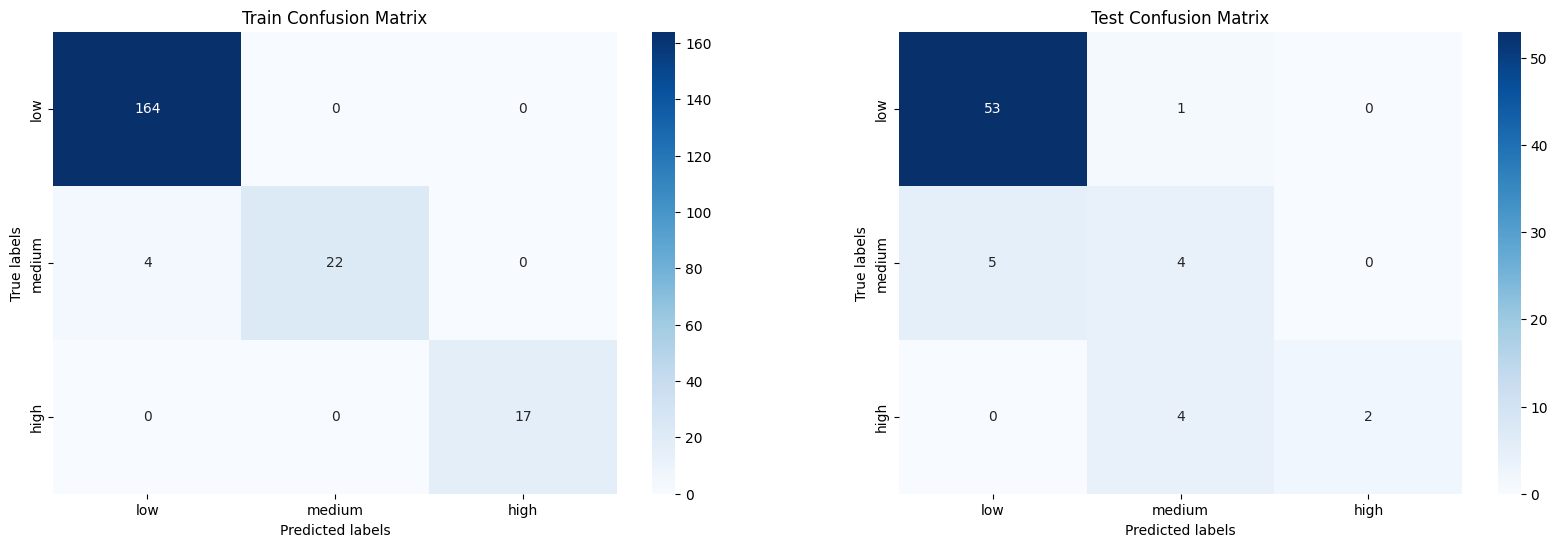

In [99]:
cm_train = confusion_matrix(y_train, y_pred_train)
if not train_test_only:
  cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

if not train_test_only:
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))
else:
  fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
if not train_test_only:
  sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[2], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
else:
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)

if not train_test_only:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Validation Confusion Matrix')
  axes[2].set_title('Test Confusion Matrix')
else:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Test Confusion Matrix')

for ax in axes:
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.show()

## Majority vote

In [100]:
# create zero majority vectors
zero_vector_train = np.zeros_like(y_train)
if not train_test_only:
  zero_vector_val = np.zeros_like(y_val)
zero_vector_test = np.zeros_like(y_test)

# print classification reports
print('Test Classification Report: \n', classification_report(y_test, zero_vector_test, zero_division=1))
test_probs = [[1, 0, 0] for _ in range(len(y_test))]

roc_auc_score(y_test, test_probs, multi_class='ovr')

Test Classification Report: 
               precision    recall  f1-score   support

           0       0.78      1.00      0.88        54
           1       1.00      0.00      0.00         9
           3       1.00      0.00      0.00         6

    accuracy                           0.78        69
   macro avg       0.93      0.33      0.29        69
weighted avg       0.83      0.78      0.69        69



0.5

In [101]:
# Saving
df_train = pd.DataFrame({'text': X_train.text,
                         'ground_truth': y_train,
                         'model_prediction': y_pred_train})
df_train.to_csv(f'model_{model_info}_train.csv', index=False)

# For the validation set, only if train_test_only is not True
if not train_test_only:
    df_val = pd.DataFrame({'text': X_val.text,
                           'ground_truth': y_val,
                           'model_prediction': y_pred_val})
    df_val.to_csv(f'model_{model_info}_validation.csv', index=False)

# For the test set
df_test = pd.DataFrame({'text': X_test.text,
                        'ground_truth': y_test,
                        'model_prediction': y_pred_test})
df_test.to_csv(f'model_{model_info}_test.csv', index=False)


#### Feature Importance - model 2

In [102]:
# Using Random Forest
feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names) + train_toxicity_df.columns.to_list() + train_questions_df.columns.to_list()

rf_2.fit(X_train_toxicity, y_train)

importances = rf_2.feature_importances_

feat_importances = dict(zip(feature_names, importances))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


Feature: question_6_Does he frequently make her feel guilty?, Importance: 0.03909
Feature: question_11_Does he exhibit a tendency for angry outbursts?, Importance: 0.0344
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: 0.0258
Feature: question_15_Does she describe verbal violence from her partner? (e.g. name calling/humilation), Importance: 0.02089
Feature: question_4_Does she mention avoiding social events or outings with friends or family because of him or maybe making excuses for not going out?, Importance: 0.01739
Feature: question_9_Does she feel she doesn't have option to leave him?, Importance: 0.01656
Feature: threaten, Importance: 0.01594
Feature: accus, Importance: 0.01085
Feature: question_8_Does he try to manipulate her?, Importance: 0.00966
Feature: minut, Importance: 0.00946


In [103]:
# Using Logistic Regression
lr.fit(X_train_toxicity, y_train)

for label in range(0,3):
  print('##########################')
  print(f"label = {label}")
  coef = lr.coef_[label]
  feat_importances = dict(zip(feature_names, coef))
  print(f"highest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")

  print(f"lowest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=False)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


##########################
label = 0
highest:
Feature: upset, Importance: 0.34597
Feature: friend, Importance: 0.30897
Feature: understand, Importance: 0.30526
Feature: im, Importance: 0.25121
Feature: whi, Importance: 0.23735
Feature: ask, Importance: 0.20358
Feature: someth, Importance: 0.18869
Feature: care, Importance: 0.18818
Feature: group, Importance: 0.16126
Feature: anymor, Importance: 0.15615
lowest:
Feature: question_11_Does he exhibit a tendency for angry outbursts?, Importance: -1.40023
Feature: question_9_Does she feel she doesn't have option to leave him?, Importance: -1.23246
Feature: question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?, Importance: -1.2317
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: -1.11222
Feature: question_13_Does she mention that he was physically violent to her?, Importance: -1.08139
Feature: question_8_Does he try to man

### Model 3 - bag of words features, predicting subjective question

In [104]:
model_info = '3_bag_of_words'

In [105]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=1000, min_df=5, stop_words='english')

X_train_bow = count_vectorizer.fit_transform(X_train['clean_text'])

if not train_test_only:
  X_val_bow = count_vectorizer.transform(X_val['clean_text'])

X_test_bow = count_vectorizer.transform(X_test['clean_text'])


In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_3 = RandomForestClassifier()
lr_3 = LogisticRegression()

voting_clf_3 = VotingClassifier(estimators=[('lr', lr_3), ('rf', rf_3)], voting='soft')
voting_clf_3.fit(X_train_bow, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier())],
                 voting='soft')

In [107]:
# Model Evaluation
y_pred_train = voting_clf_3.predict(X_train_bow)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

if not train_test_only:
  y_pred_val = voting_clf_3.predict(X_val_bow)
  print(f'Validation results: \n{classification_report(y_val, y_pred_val, target_names = label_columns)}')

y_pred_test = voting_clf_3.predict(X_test_bow)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       1.00      1.00      1.00       164
      medium       1.00      1.00      1.00        26
        high       1.00      1.00      1.00        17

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207

Test results: 
              precision    recall  f1-score   support

         low       0.79      0.96      0.87        54
      medium       0.00      0.00      0.00         9
        high       1.00      0.17      0.29         6

    accuracy                           0.77        69
   macro avg       0.60      0.38      0.38        69
weighted avg       0.70      0.77      0.70        69



In [108]:
# ROC AUC
train_probs = voting_clf_3.predict_proba(X_train_bow)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf_3.predict_proba(X_val_bow)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs, multi_class='ovo'))

test_probs = voting_clf_3.predict_proba(X_test_bow)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class='ovo'))



Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.7131344307270232


confusion matrix

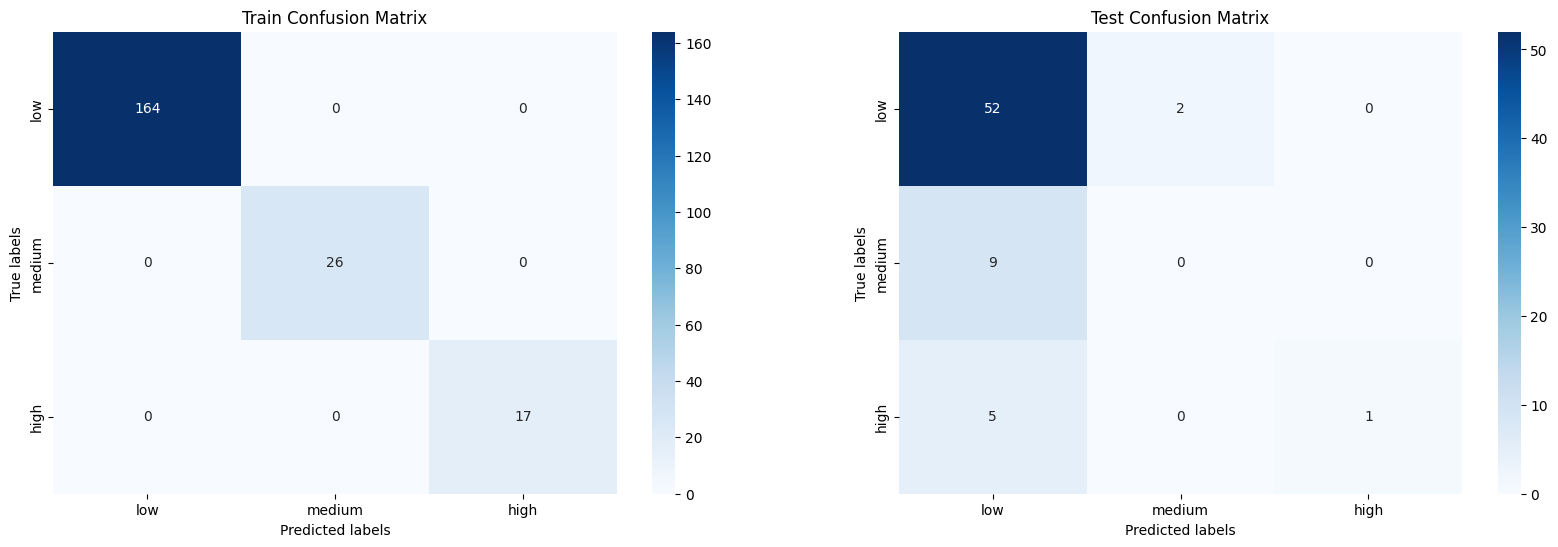

In [109]:
cm_train = confusion_matrix(y_train, y_pred_train)
if not train_test_only:
  cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

if not train_test_only:
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))
else:
  fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
if not train_test_only:
  sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[2], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
else:
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)

if not train_test_only:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Validation Confusion Matrix')
  axes[2].set_title('Test Confusion Matrix')
else:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Test Confusion Matrix')

for ax in axes:
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.show()

In [111]:
# Saving
df_train = pd.DataFrame({'text': X_train.text,
                         'ground_truth': y_train,
                         'model_prediction': y_pred_train})
df_train.to_csv(f'model_{model_info}_train.csv', index=False)

# For the validation set, only if train_test_only is not True
if not train_test_only:
    df_val = pd.DataFrame({'text': X_val.text,
                           'ground_truth': y_val,
                           'model_prediction': y_pred_val})
    df_val.to_csv(f'model_{model_info}_validation.csv', index=False)

# For the test set
df_test = pd.DataFrame({'text': X_test.text,
                        'ground_truth': y_test,
                        'model_prediction': y_pred_test})
df_test.to_csv(f'model_{model_info}_test.csv', index=False)


#### Feature Importance

In [112]:
# Using Random Forest
feature_names = tfidf.get_feature_names_out()

rf_3.fit(X_train_bow, y_train)

importances = rf_3.feature_importances_

feat_importances = dict(zip(feature_names, importances))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


Feature: panick, Importance: 0.01348
Feature: saw, Importance: 0.01136
Feature: introduc, Importance: 0.0103
Feature: text, Importance: 0.01023
Feature: word, Importance: 0.00974
Feature: fit, Importance: 0.00932
Feature: accept, Importance: 0.00823
Feature: walk, Importance: 0.00806
Feature: lone, Importance: 0.00787
Feature: respect, Importance: 0.00777


In [113]:
# Using Logistic Regression
lr_3.fit(X_train_bow, y_train)
coef = lr_3.coef_[0]
feat_importances = dict(zip(feature_names, coef))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True):
    print(f"Feature: {feat}, Coefficient: {importance}")


Feature: light, Coefficient: 0.2675254832453369
Feature: defens, Coefficient: 0.2513220483677596
Feature: door, Coefficient: 0.233704926253715
Feature: argu, Coefficient: 0.23355419358498422
Feature: man, Coefficient: 0.20003596149049027
Feature: gf, Coefficient: 0.1927011449426083
Feature: constant, Coefficient: 0.18491456828243638
Feature: better, Coefficient: 0.16881410265609692
Feature: hate, Coefficient: 0.16562240465009456
Feature: watch, Coefficient: 0.16226964581583536
Feature: begin, Coefficient: 0.1594591285533452
Feature: decid, Coefficient: 0.15881702556948069
Feature: veri, Coefficient: 0.1583778109844201
Feature: figur, Coefficient: 0.14960712718703503
Feature: yell, Coefficient: 0.14904741297071009
Feature: outsid, Coefficient: 0.1475077513529266
Feature: physic, Coefficient: 0.1443503901569913
Feature: husband, Coefficient: 0.1407659798015072
Feature: harass, Coefficient: 0.14046626638551268
Feature: particular, Coefficient: 0.13293604588701383
Feature: parti, Coefficie

### Model 4 - tf-df with stemming, questions and toxicity features, predicting subjective question

In [114]:
# pip install nltk
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [115]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer('english')

def stem_text(text):
    clean_text_ = clean_text(text)
    tokens = nltk.word_tokenize(clean_text_)
    stems = [stemmer.stem(token) for token in tokens]
    return stems

tfidf = TfidfVectorizer(max_features=1000, tokenizer=stem_text, stop_words='english', min_df=5)

X_train_tfidf = tfidf.fit_transform(X_train['text'])
if not train_test_only:
  X_val_tfidf = tfidf.transform(X_val['text'])
X_test_tfidf = tfidf.transform(X_test['text'])


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [116]:
model_info = '4_tfidf_stemming_questions_TOXICITY'

In [117]:
train_questions_df = X_train[X_train.columns[X_train.columns.str.startswith('question')]]
train_toxicity_df = X_train[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_train_toxicity = pd.concat([pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index), train_toxicity_df, train_questions_df], axis=1)
X_train_toxicity.columns = X_train_toxicity.columns.astype(str)

if not train_test_only:
  val_questions_df = X_val[X_val.columns[X_val.columns.str.startswith('question')]]
  val_toxicity_df = X_val[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
  X_val_toxicity = pd.concat([pd.DataFrame(X_val_tfidf.toarray(), index=X_val.index), val_toxicity_df, val_questions_df], axis=1)
  X_val_toxicity.columns = X_val_toxicity.columns.astype(str)


test_questions_df = X_test[X_test.columns[X_test.columns.str.startswith('question')]]
test_toxicity_df = X_test[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_test_toxicity = pd.concat([pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index), test_toxicity_df, test_questions_df], axis=1)
X_test_toxicity.columns = X_test_toxicity.columns.astype(str)


In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_4 = RandomForestClassifier()
lr_4 = LogisticRegression(max_iter=1000)
voting_clf_4 = VotingClassifier(estimators=[('lr', lr_4), ('rf', rf_4)], voting='soft')
voting_clf_4.fit(X_train_toxicity, y_train)


VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('rf', RandomForestClassifier())],
                 voting='soft')

In [119]:
# Model Evaluation
y_pred_train = voting_clf_4.predict(X_train_toxicity)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

if not train_test_only:
  y_pred_val = voting_clf_4.predict(X_val_toxicity)
  print(f'Validation results: \n{classification_report(y_val, y_pred_val, target_names = label_columns)}')

y_pred_test = voting_clf_4.predict(X_test_toxicity)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       0.99      1.00      1.00       164
      medium       1.00      0.96      0.98        26
        high       1.00      1.00      1.00        17

    accuracy                           1.00       207
   macro avg       1.00      0.99      0.99       207
weighted avg       1.00      1.00      1.00       207

Test results: 
              precision    recall  f1-score   support

         low       0.91      0.96      0.94        54
      medium       0.40      0.44      0.42         9
        high       1.00      0.33      0.50         6

    accuracy                           0.84        69
   macro avg       0.77      0.58      0.62        69
weighted avg       0.85      0.84      0.83        69



In [120]:
# ROC AUC
train_probs = voting_clf_4.predict_proba(X_train_toxicity)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf_4.predict_proba(X_val_toxicity)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs, multi_class='ovo'))

test_probs = voting_clf_4.predict_proba(X_test_toxicity)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class='ovo'))



Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.867798353909465


confusion matrix

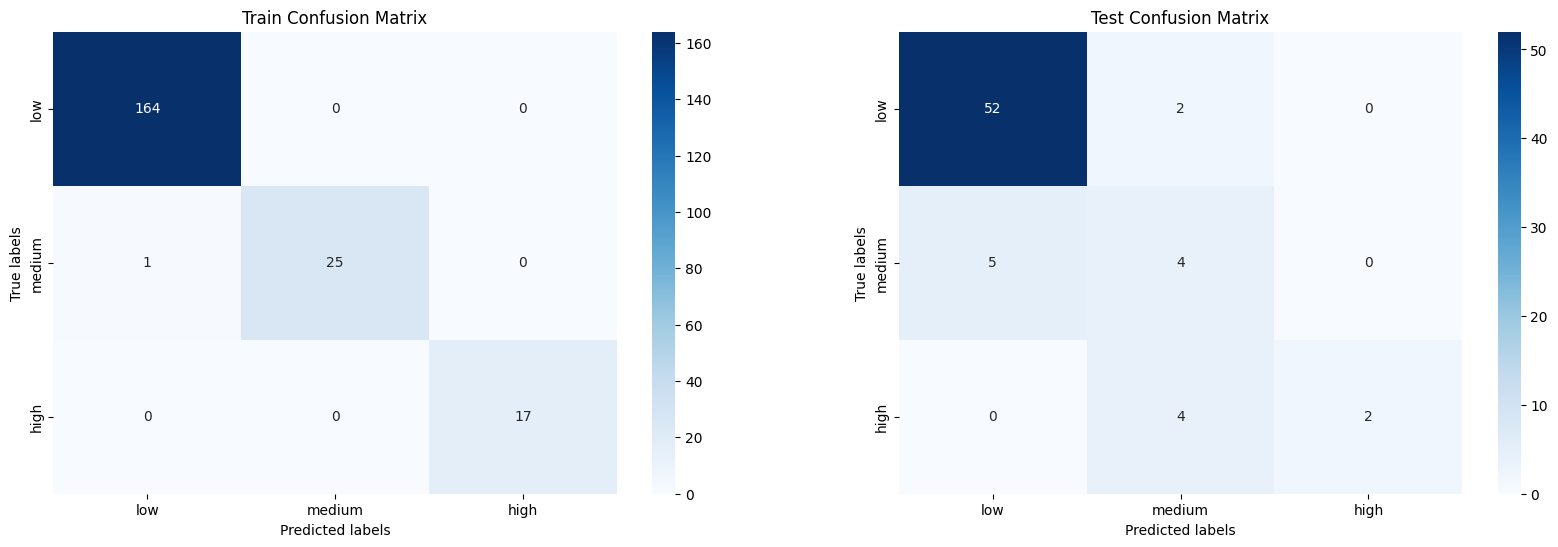

In [121]:
cm_train = confusion_matrix(y_train, y_pred_train)
if not train_test_only:
  cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

if not train_test_only:
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))
else:
  fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
if not train_test_only:
  sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[2], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
else:
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)

if not train_test_only:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Validation Confusion Matrix')
  axes[2].set_title('Test Confusion Matrix')
else:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Test Confusion Matrix')

for ax in axes:
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.show()

In [123]:
# Saving
df_train = pd.DataFrame({'text': X_train.text,
                         'ground_truth': y_train,
                         'model_prediction': y_pred_train})
df_train.to_csv(f'model_{model_info}_train.csv', index=False)

# For the validation set, only if train_test_only is not True
if not train_test_only:
    df_val = pd.DataFrame({'text': X_val.text,
                           'ground_truth': y_val,
                           'model_prediction': y_pred_val})
    df_val.to_csv(f'model_{model_info}_validation.csv', index=False)

# For the test set
df_test = pd.DataFrame({'text': X_test.text,
                        'ground_truth': y_test,
                        'model_prediction': y_pred_test})
df_test.to_csv(f'model_{model_info}_test.csv', index=False)


#### Feature selectio - model 2

In [124]:
# Using Random Forest
feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names) + train_toxicity_df.columns.to_list() + train_questions_df.columns.to_list()

rf_4.fit(X_train_toxicity, y_train)

importances = rf_4.feature_importances_

feat_importances = dict(zip(feature_names, importances))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:20]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


Feature: question_11_Does he exhibit a tendency for angry outbursts?, Importance: 0.02941
Feature: question_15_Does she describe verbal violence from her partner? (e.g. name calling/humilation), Importance: 0.02772
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: 0.0244
Feature: question_6_Does he frequently make her feel guilty?, Importance: 0.02427
Feature: question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?, Importance: 0.01842
Feature: question_8_Does he try to manipulate her?, Importance: 0.01259
Feature: question_4_Does she mention avoiding social events or outings with friends or family because of him or maybe making excuses for not going out?, Importance: 0.01225
Feature: minut, Importance: 0.0121
Feature: threaten, Importance: 0.01052
Feature: question_9_Does she feel she doesn't have option to leave him?, Importance: 0.00992
Feature: mom, Importance: 0.0

In [125]:
print(f"number features: {len(feature_names)}")

number features: 945


In [126]:
# Using Logistic Regression
lr_4.fit(X_train_toxicity, y_train)

for label in range(0,3):
  print('##########################')
  print(f"label = {label}")
  coef = lr_4.coef_[label]
  feat_importances = dict(zip(feature_names, coef))
  print(f"highest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")

  print(f"lowest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=False)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


##########################
label = 0
highest:
Feature: upset, Importance: 0.34597
Feature: friend, Importance: 0.30897
Feature: understand, Importance: 0.30526
Feature: im, Importance: 0.25121
Feature: whi, Importance: 0.23735
Feature: ask, Importance: 0.20358
Feature: someth, Importance: 0.18869
Feature: care, Importance: 0.18818
Feature: group, Importance: 0.16126
Feature: anymor, Importance: 0.15615
lowest:
Feature: question_11_Does he exhibit a tendency for angry outbursts?, Importance: -1.40023
Feature: question_9_Does she feel she doesn't have option to leave him?, Importance: -1.23246
Feature: question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?, Importance: -1.2317
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: -1.11222
Feature: question_13_Does she mention that he was physically violent to her?, Importance: -1.08139
Feature: question_8_Does he try to man

### Model 5 -  tf-df, questions and toxicity features, predicting subjective question * balance the classes according to their distribution.

In [127]:
model_info = '5_balanced_tfidf_questions_TOXICITY'

In [151]:
train_questions_df = X_train[X_train.columns[X_train.columns.str.startswith('question')]]
train_toxicity_df = X_train[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_train_toxicity = pd.concat([pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index), train_toxicity_df, train_questions_df], axis=1)
X_train_toxicity.columns = X_train_toxicity.columns.astype(str)

if not train_test_only:
  val_questions_df = X_val[X_val.columns[X_val.columns.str.startswith('question')]]
  val_toxicity_df = X_val[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
  X_val_toxicity = pd.concat([pd.DataFrame(X_val_tfidf.toarray(), index=X_val.index), val_toxicity_df, val_questions_df], axis=1)
  X_val_toxicity.columns = X_val_toxicity.columns.astype(str)


test_questions_df = X_test[X_test.columns[X_test.columns.str.startswith('question')]]
test_toxicity_df = X_test[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_test_toxicity = pd.concat([pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index), test_toxicity_df, test_questions_df], axis=1)
X_test_toxicity.columns = X_test_toxicity.columns.astype(str)


In [152]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_5 = RandomForestClassifier(class_weight='balanced')
lr_5 = LogisticRegression(class_weight='balanced', max_iter=1000)

voting_clf_5 = VotingClassifier(estimators=[('lr', lr_5), ('rf', rf_5)], voting='soft')
voting_clf_5.fit(X_train_toxicity, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced'))],
                 voting='soft')

In [153]:
# Model Evaluation
y_pred_train = voting_clf_5.predict(X_train_toxicity)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

if not train_test_only:
  y_pred_val = voting_clf_5.predict(X_val_toxicity)
  print(f'Validation results: \n{classification_report(y_val, y_pred_val, target_names = label_columns)}')

y_pred_test = voting_clf_5.predict(X_test_toxicity)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       1.00      1.00      1.00       164
      medium       1.00      1.00      1.00        26
        high       1.00      1.00      1.00        17

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207

Test results: 
              precision    recall  f1-score   support

         low       0.94      0.93      0.93        54
      medium       0.46      0.67      0.55         9
        high       1.00      0.50      0.67         6

    accuracy                           0.86        69
   macro avg       0.80      0.70      0.72        69
weighted avg       0.89      0.86      0.86        69



In [154]:
# ROC AUC
train_probs = voting_clf_5.predict_proba(X_train_toxicity)
print("Train ROC AUC Score: ", roc_auc_score(y_train, train_probs, multi_class='ovo'))

if not train_test_only:
  val_probs = voting_clf_5.predict_proba(X_val_toxicity)
  print("Validation ROC AUC Score: ", roc_auc_score(y_val, val_probs, multi_class='ovo'))

test_probs = voting_clf_5.predict_proba(X_test_toxicity)
print("Test ROC AUC Score: ", roc_auc_score(y_test, test_probs, multi_class='ovo'))



Train ROC AUC Score:  1.0
Test ROC AUC Score:  0.8629972565157752


confusion matrix

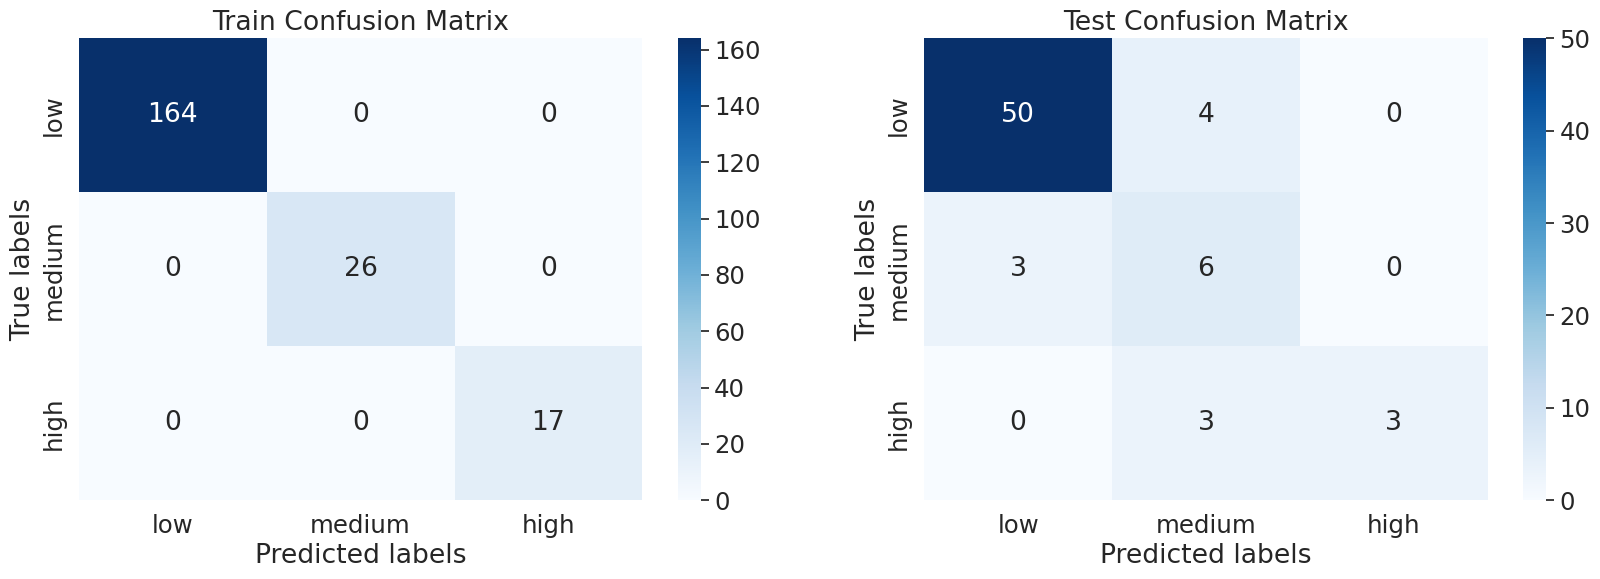

In [155]:
cm_train = confusion_matrix(y_train, y_pred_train)
if not train_test_only:
  cm_val = confusion_matrix(y_val, y_pred_val)
cm_test = confusion_matrix(y_test, y_pred_test)

if not train_test_only:
  fig, axes = plt.subplots(1, 3, figsize=(20, 6))
else:
  fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
if not train_test_only:
  sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[2], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
else:
  sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=label_columns, yticklabels=label_columns)
sns.set(font_scale=1.6)
if not train_test_only:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Validation Confusion Matrix')
  axes[2].set_title('Test Confusion Matrix')
else:
  axes[0].set_title('Train Confusion Matrix')
  axes[1].set_title('Test Confusion Matrix')

for ax in axes:
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')

plt.show()

Missclassification rate and indices - model 5

In [133]:
# missclassification
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Get unique labels from y_test
labels = [0, 1, 3]

# Calculate misclassification rate for each label
misclassification_rates = []
for i, label in enumerate(labels):
    correct_predictions = cm[i][i]
    total_predictions = cm[i , :].sum()
    misclassification_rate = 1 - (correct_predictions / total_predictions)
    misclassification_rates.append(misclassification_rate)

# Print misclassification rates for each label
for label, rate in zip(labels, misclassification_rates):
    print(f'Misclassification rate for label {label}: {rate}')

Misclassification rate for label 0: 0.07407407407407407
Misclassification rate for label 1: 0.2222222222222222
Misclassification rate for label 3: 0.5


In [134]:
model15_df = X_test.copy()
model15_df['y_pred_test'] = y_pred_test
model15_df['y_test'] = y_test
model15_df['missclassified'] = model15_df['y_test'] != model15_df['y_pred_test']
model15_df[model15_df['missclassified']].index

Int64Index([189, 294, 254, 37, 270, 266, 79, 29, 204], dtype='int64')

In [136]:
# Saving
df_train = pd.DataFrame({'text': X_train.text,
                         'ground_truth': y_train,
                         'model_prediction': y_pred_train})
df_train.to_csv(f'model_{model_info}_train.csv', index=False)

# For the validation set, only if train_test_only is not True
if not train_test_only:
    df_val = pd.DataFrame({'text': X_val.text,
                           'ground_truth': y_val,
                           'model_prediction': y_pred_val})
    df_val.to_csv(f'model_{model_info}_validation.csv', index=False)

# For the test set
df_test = pd.DataFrame({'text': X_test.text,
                        'ground_truth': y_test,
                        'model_prediction': y_pred_test})
df_test.to_csv(f'model_{model_info}_test.csv', index=False)


#### Feature Importance - model 5

In [137]:
# Using Random Forest
feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names) + train_toxicity_df.columns.to_list() + train_questions_df.columns.to_list()

rf_5.fit(X_train_toxicity, y_train)

importances = rf_5.feature_importances_

feat_importances = dict(zip(feature_names, importances))

for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:20]:
    print(f"Feature: {feat}, Importance: {round(importance, 4)}")


Feature: question_15_Does she describe verbal violence from her partner? (e.g. name calling/humilation), Importance: 0.0272
Feature: question_8_Does he try to manipulate her?, Importance: 0.0195
Feature: question_6_Does he frequently make her feel guilty?, Importance: 0.0195
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: 0.0164
Feature: THREAT, Importance: 0.0158
Feature: IDENTITY_ATTACK, Importance: 0.0126
Feature: say, Importance: 0.0108
Feature: know, Importance: 0.0101
Feature: anoth, Importance: 0.0097
Feature: PROFANITY, Importance: 0.0087
Feature: hurt, Importance: 0.0085
Feature: question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?, Importance: 0.0083
Feature: make, Importance: 0.0081
Feature: TOXICITY, Importance: 0.008
Feature: just, Importance: 0.008
Feature: thing, Importance: 0.0078
Feature: question_11_Does he exhibit a tendency for angry outbursts?

In [138]:
# Using Logistic Regression
lr_5.fit(X_train_toxicity, y_train)
for label in range(0,3):
  print('##########################')
  print(f"label = {label}")
  coef = lr_5.coef_[label]
  feat_importances = dict(zip(feature_names, coef))
  print(f"highest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")

  print(f"lowest:")
  for feat, importance in sorted(feat_importances.items(), key=lambda item: item[1], reverse=False)[:10]:
    print(f"Feature: {feat}, Importance: {round(importance, 5)}")


##########################
label = 0
highest:
Feature: friend, Importance: 0.31715
Feature: understand, Importance: 0.30361
Feature: upset, Importance: 0.28863
Feature: whi, Importance: 0.24308
Feature: im, Importance: 0.21117
Feature: ask, Importance: 0.20424
Feature: group, Importance: 0.18783
Feature: someth, Importance: 0.18692
Feature: care, Importance: 0.17431
Feature: wrong, Importance: 0.14702
lowest:
Feature: question_11_Does he exhibit a tendency for angry outbursts?, Importance: -1.42863
Feature: question_7_Does he frequently express dissatisfaction with her?, Importance: -1.3415
Feature: question_12_Does she ever feel unsafe or threatened by him? Or does it seem evident from the post that he threatened/stalked/harassed her?, Importance: -1.29588
Feature: question_9_Does she feel she doesn't have option to leave him?, Importance: -1.2554
Feature: question_13_Does she mention that he was physically violent to her?, Importance: -1.21068
Feature: question_8_Does he try to manip

### model 5.5 - model 5 + Feature Selection

In [139]:
from nltk.stem import SnowballStemmer
import nltk
nltk.download('punkt')
stemmer = SnowballStemmer('english')

def stem_text(text):
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(token) for token in tokens]
    return stems

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [140]:
tfidf = TfidfVectorizer(max_features=1000, tokenizer=stem_text, stop_words='english', min_df=5)
X_train_tfidf = tfidf.fit_transform(X_train['clean_text'])
if not train_test_only:
  X_val_tfidf = tfidf.transform(X_val['clean_text'])
X_test_tfidf = tfidf.transform(X_test['clean_text'])

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [141]:
train_questions_df = X_train[X_train.columns[X_train.columns.str.startswith('question')]]
train_toxicity_df = X_train[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_train_toxicity = pd.concat([pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index), train_toxicity_df, train_questions_df], axis=1)
X_train_toxicity.columns = X_train_toxicity.columns.astype(str)

if not train_test_only:
  val_questions_df = X_val[X_val.columns[X_val.columns.str.startswith('question')]]
  val_toxicity_df = X_val[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
  X_val_toxicity = pd.concat([pd.DataFrame(X_val_tfidf.toarray(), index=X_val.index), val_toxicity_df, val_questions_df], axis=1)
  X_val_toxicity.columns = X_val_toxicity.columns.astype(str)


test_questions_df = X_test[X_test.columns[X_test.columns.str.startswith('question')]]
test_toxicity_df = X_test[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_test_toxicity = pd.concat([pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index), test_toxicity_df, test_questions_df], axis=1)
X_test_toxicity.columns = X_test_toxicity.columns.astype(str)

In [142]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif


KBest_selector = SelectKBest(score_func=f_classif, k=100)

selected_features_matrix = KBest_selector.fit_transform(X_train_toxicity, y_train)
# Get columns to keep
cols = KBest_selector.get_support(indices=True)

# Create new dataframe with only the desired columns
X_train_toxicity_selected = X_train_toxicity.iloc[:, cols]
X_test_toxicity_selected = X_test_toxicity.iloc[:, cols]

feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names) + train_toxicity_df.columns.to_list() + train_questions_df.columns.to_list()
features_names_selected = [f for i, f in enumerate(feature_names) if i in cols]

features_names_selected[:10]

['abus',
 'accus',
 'afraid',
 'aggress',
 'allow',
 'alway',
 'amaz',
 'angri',
 'anymor',
 'anytim']

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_5 = RandomForestClassifier(class_weight='balanced')
lr_5 = LogisticRegression(class_weight='balanced', max_iter=1000)

voting_clf_5 = VotingClassifier(estimators=[('lr', lr_5), ('rf', rf_5)], voting='soft')
voting_clf_5.fit(X_train_toxicity_selected, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced'))],
                 voting='soft')

In [144]:
# Model Evaluation
y_pred_train = voting_clf_5.predict(X_train_toxicity_selected)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

y_pred_test = voting_clf_5.predict(X_test_toxicity_selected)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       1.00      0.99      0.99       164
      medium       0.93      1.00      0.96        26
        high       1.00      1.00      1.00        17

    accuracy                           0.99       207
   macro avg       0.98      1.00      0.99       207
weighted avg       0.99      0.99      0.99       207

Test results: 
              precision    recall  f1-score   support

         low       0.94      0.91      0.92        54
      medium       0.36      0.56      0.43         9
        high       0.67      0.33      0.44         6

    accuracy                           0.81        69
   macro avg       0.66      0.60      0.60        69
weighted avg       0.84      0.81      0.82        69



### Model 6 - tfidf features + toxicity + selection + subjective

In [145]:
train_questions_df = X_train[X_train.columns[X_train.columns.str.startswith('question')]]
train_toxicity_df = X_train[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_train_toxicity = pd.concat([pd.DataFrame(X_train_tfidf.toarray(), index=X_train.index), train_toxicity_df], axis=1)
X_train_toxicity.columns = X_train_toxicity.columns.astype(str)

if not train_test_only:
  val_questions_df = X_val[X_val.columns[X_val.columns.str.startswith('question')]]
  val_toxicity_df = X_val[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
  X_val_toxicity = pd.concat([pd.DataFrame(X_val_tfidf.toarray(), index=X_val.index), val_toxicity_df], axis=1)
  X_val_toxicity.columns = X_val_toxicity.columns.astype(str)


test_questions_df = X_test[X_test.columns[X_test.columns.str.startswith('question')]]
test_toxicity_df = X_test[['TOXICITY', 'THREAT', 'PROFANITY', 'INSULT', 'IDENTITY_ATTACK']]
X_test_toxicity = pd.concat([pd.DataFrame(X_test_tfidf.toarray(), index=X_test.index), test_toxicity_df], axis=1)
X_test_toxicity.columns = X_test_toxicity.columns.astype(str)

In [146]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif


KBest_selector = SelectKBest(score_func=f_classif, k=30)

selected_features_matrix = KBest_selector.fit_transform(X_train_toxicity, y_train)
# Get columns to keep
cols = KBest_selector.get_support(indices=True)

# Create new dataframe with only the desired columns
X_train_toxicity_selected = X_train_toxicity.iloc[:, cols]
X_test_toxicity_selected = X_test_toxicity.iloc[:, cols]

feature_names = tfidf.get_feature_names_out()
feature_names = list(feature_names) + train_toxicity_df.columns.to_list() + train_questions_df.columns.to_list()
features_names_selected = [f for i, f in enumerate(feature_names) if i in cols]

features_names_selected[:40]

['abus',
 'accus',
 'aggress',
 'allow',
 'apolog',
 'bad',
 'beg',
 'boy',
 'cours',
 'disagr',
 'door',
 'fight',
 'fix',
 'guilt',
 'hurt',
 'lay',
 'manipul',
 'minut',
 'mom',
 'nowher',
 'pain',
 'posit',
 'pregnant',
 'quick',
 'react',
 'realiz',
 's',
 'threaten',
 'wall',
 'THREAT']

In [147]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf_5 = RandomForestClassifier(class_weight='balanced')
lr_5 = LogisticRegression(class_weight='balanced', max_iter=1000)

voting_clf_5 = VotingClassifier(estimators=[('lr', lr_5), ('rf', rf_5)], voting='soft')
voting_clf_5.fit(X_train_toxicity_selected, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(class_weight='balanced',
                                                 max_iter=1000)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced'))],
                 voting='soft')

In [148]:
# Model Evaluation
y_pred_train = voting_clf_5.predict(X_train_toxicity_selected)
print(f'Training results: \n {classification_report(y_train, y_pred_train, target_names = label_columns)}')

y_pred_test = voting_clf_5.predict(X_test_toxicity_selected)
print(f'Test results: \n{classification_report(y_test, y_pred_test, target_names = label_columns)}')

Training results: 
               precision    recall  f1-score   support

         low       1.00      1.00      1.00       164
      medium       1.00      1.00      1.00        26
        high       1.00      1.00      1.00        17

    accuracy                           1.00       207
   macro avg       1.00      1.00      1.00       207
weighted avg       1.00      1.00      1.00       207

Test results: 
              precision    recall  f1-score   support

         low       0.79      1.00      0.89        54
      medium       1.00      0.11      0.20         9
        high       0.00      0.00      0.00         6

    accuracy                           0.80        69
   macro avg       0.60      0.37      0.36        69
weighted avg       0.75      0.80      0.72        69



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
